# PySR Symbolic Regression — Hoop EOM Discovery from IMU Data

**2 Algorithms**: Standard PySR, Hybrid PySR (pooled runs)

**Sweep axes**: parsimony × maxsize × library (Base / Full)

**3 Metrics**: MSE, ATE (A/B/C/D/F), R²

**5 Runs**: Hoop IMU data at 120 Hz | **3 DOFs**: a_x, a_y, a_z

| Sweep param | Values | Purpose |
|---|---|---|
| parsimony | 0.01, 0.1 | Complexity penalty (like SINDy threshold) |
| maxsize | 15, 25 | Expression cap (like SINDy library size) |
| library | Base (6 feat), Full (15 feat) | Feature set (±angular velocity & sin/cos of euler) |

**Total fits**: 2 × 2 × 2 × 2 × 5 × 3 = 240

ATE grading: A < 0.01, B < 0.05, C < 0.15, D < 0.50, F >= 0.50

In [17]:
import sys, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, filtfilt, savgol_filter, medfilt
from scipy.integrate import cumulative_trapezoid
from IPython.display import display, HTML
warnings.filterwarnings('ignore')

DATA_DIR = Path(r"C:\Users\braid\OneDrive\Desktop\Data Driven Modeling Project\hoop data")
sys.path.insert(0, str(DATA_DIR))
from run_sindy_analysis import preprocess_hoop_data, detrend_custom
from pysr import PySRRegressor

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 1e-20 else 0.0

def compute_open_loop_ate(y_pred_seg, q_true_seg, u_true_seg, dt):
    n = len(y_pred_seg)
    if n < 2:
        return 0.0
    q_sim = np.zeros(n)
    u_sim = np.zeros(n)
    q_sim[0] = q_true_seg[0]
    u_sim[0] = u_true_seg[0]
    for i in range(n - 1):
        u_sim[i + 1] = u_sim[i] + y_pred_seg[i] * dt
        q_sim[i + 1] = q_sim[i] + u_sim[i + 1] * dt
    return float(np.sqrt(np.mean((q_true_seg - q_sim) ** 2)))

def ate_grade(ate):
    if not np.isfinite(ate): return 'F'
    if ate < 0.01: return 'A'
    if ate < 0.05: return 'B'
    if ate < 0.15: return 'C'
    if ate < 0.50: return 'D'
    return 'F'

def safe_predict(model, X):
    y = model.predict(X)
    mask = ~np.isfinite(y)
    if mask.any():
        y[mask] = np.nanmean(y[~mask]) if (~mask).any() else 0.0
    return y

DOF_LABELS = ['a_x', 'a_y', 'a_z']

print('Imports loaded.')

Imports loaded.


## S1 — Data Loading & Splits

In [18]:
FS = 120
CUTOFF_ACC, CUTOFF_GYR = 20, 15
SG_WIN, SG_ORD = 11, 3

CSV_FILES = {
    'run_1': 'OR_20250903_203926.csv',
    'run_2': 'OR_20250903_204044.csv',
    'run_3': 'OR_20250903_204119.csv',
    'run_4': 'OR_20250903_204158.csv',
    'run_5': 'OR_D422CD005685_20250903_204229.csv',
}

def butter_lp(data, cutoff, fs, order=4):
    b, a = butter(order, cutoff / (0.5 * fs), btype='low')
    if data.ndim == 1: return filtfilt(b, a, data)
    return np.column_stack([filtfilt(b, a, data[:, i]) for i in range(data.shape[1])])

def butter_hp(data, cutoff, fs, order=2):
    b, a = butter(order, cutoff / (0.5 * fs), btype='high')
    return filtfilt(b, a, data)

def clip_iqr(data, k=3.0):
    out = data.copy()
    for i in range(data.shape[1]):
        q1, q3 = np.percentile(data[:, i], [25, 75])
        iqr = q3 - q1
        out[:, i] = np.clip(data[:, i], q1 - k * iqr, q3 + k * iqr)
    return out

def regime_aware_split_hoop(acc, train_frac=0.60, val_frac=0.20,
                             window=15, percentile=60, min_group_size=50):
    """Split preserving proportional low/high dynamics in every subset.

    Labels each timestep as low (0) or high (1) dynamics via median-filtered
    acceleration magnitude vs. 60th-percentile threshold. Within each regime
    group takes the first train_frac for train, next val_frac for val, remainder
    for test (temporal order preserved). Groups < min_group_size go to training.
    Returns idx_train, idx_val, idx_test, regime_labels (0/1 per timestep).
    """
    mag = np.linalg.norm(acc, axis=1)
    mag_s = medfilt(mag, kernel_size=window)
    thresh = np.percentile(mag_s, percentile)
    regime_labels = (mag_s >= thresh).astype(int)   # 0=low, 1=high

    idx_train, idx_val, idx_test = [], [], []
    for reg_id in [0, 1]:
        group = np.where(regime_labels == reg_id)[0]
        n = len(group)
        if n == 0:
            continue
        if n < min_group_size:
            idx_train.append(group)
            continue
        n_tr = max(1, int(train_frac * n))
        n_va = max(1, min(int(val_frac * n), n - n_tr - 1))
        n_te = n - n_tr - n_va
        idx_train.append(group[:n_tr])
        idx_val.append(group[n_tr:n_tr + n_va])
        if n_te > 0:
            idx_test.append(group[n_tr + n_va:])

    idx_train = np.sort(np.concatenate(idx_train)) if idx_train else np.arange(0)
    idx_val   = np.sort(np.concatenate(idx_val))   if idx_val   else np.arange(0)
    idx_test  = np.sort(np.concatenate(idx_test))  if idx_test  else np.arange(0)
    return idx_train, idx_val, idx_test, regime_labels

def preprocess_csv(path):
    df = pd.read_csv(path, skiprows=6)
    acc_cols = ['Acc_X', 'Acc_Y', 'Acc_Z']
    gyr_cols = ['Gyr_X', 'Gyr_Y', 'Gyr_Z']
    for c in acc_cols: df[c] = butter_lp(df[c].values, CUTOFF_ACC, FS)
    for c in gyr_cols: df[c] = butter_lp(df[c].values, CUTOFF_GYR, FS)
    arr = df[acc_cols].to_numpy()
    arr = clip_iqr(arr, k=3.0)
    for i, c in enumerate(acc_cols): df[c] = arr[:, i]
    proc = preprocess_hoop_data(df, fs=FS)
    t = proc['t']; pos = proc['position']; vel = proc['velocity']
    acc = proc['acceleration']; angles = proc['euler_angles']
    n_st = max(1, int(FS))
    acc = acc - np.median(acc[:n_st], axis=0)
    acc[:, 2] = butter_hp(acc[:, 2], 0.3, FS)
    dt = 1.0 / FS
    acc = savgol_filter(acc, SG_WIN, SG_ORD, axis=0)
    vel = savgol_filter(vel, SG_WIN, SG_ORD, axis=0)
    pos = savgol_filter(pos, SG_WIN, SG_ORD, axis=0)
    vr = np.zeros_like(acc)
    for i in range(3):
        vr[:, i] = detrend_custom(t, cumulative_trapezoid(acc[:, i], t, initial=0), degree=6)
    pr = np.zeros_like(vr)
    for i in range(3):
        pr[:, i] = detrend_custom(t, cumulative_trapezoid(vr[:, i], t, initial=0), degree=6)
    vel = savgol_filter(vr, SG_WIN, SG_ORD, axis=0)
    pos = savgol_filter(pr, SG_WIN, SG_ORD, axis=0)
    ts, te = max(5.0, float(t[0])), min(21.0, float(t[-1]))
    m = (t >= ts) & (t <= te)
    t, pos, vel, acc = t[m], pos[m], vel[m], acc[m]
    angles = angles[m]
    df2 = df.iloc[np.where(m)[0]].reset_index(drop=True)
    omega = np.deg2rad(df2[gyr_cols].to_numpy(dtype=float))
    for i in range(3): omega[:, i] = medfilt(omega[:, i], kernel_size=5)
    omega = savgol_filter(omega, SG_WIN, SG_ORD, axis=0)
    angles = np.asarray(angles, dtype=float)
    if np.nanmax(np.abs(angles)) > 7: angles = np.deg2rad(angles)
    # Angular acceleration: numerical derivative of omega, then smoothed
    alpha = np.gradient(omega, dt, axis=0)
    alpha = savgol_filter(alpha, SG_WIN, SG_ORD, axis=0)
    N = len(t)
    # Temporal split for Standard PySR
    return {'pos': pos, 'vel': vel, 'acc': acc, 'omega': omega, 'angles': angles,
            'alpha': alpha,
            't': t, 'dt': dt, 'N': N,
            'idx_train': np.arange(0, int(0.60 * N)),
            'idx_val':   np.arange(int(0.60 * N), int(0.80 * N)),
            'idx_test':  np.arange(int(0.80 * N), N)}

all_runs = {}
for name, fname in CSV_FILES.items():
    try:
        all_runs[name] = preprocess_csv(DATA_DIR / fname)
        rd = all_runs[name]
        print(f"  {name}: N={rd['N']}, t=[{rd['t'][0]:.1f},{rd['t'][-1]:.1f}]s, "
              f"temporal split={len(rd['idx_train'])}/{len(rd['idx_val'])}/{len(rd['idx_test'])}")
    except Exception as e:
        print(f"  {name}: FAILED - {e}")

RUNS = list(all_runs.keys())
print(f"\nLoaded {len(all_runs)} / {len(CSV_FILES)} runs")

# --- Standard PySR: per-run, temporal 60/20/20 ---
std_run_name = RUNS[0]
std_run = all_runs[std_run_name]
print(f'\n--- Standard PySR (temporal split per run) ---')
print(f'  train={len(std_run["idx_train"])} val={len(std_run["idx_val"])} test={len(std_run["idx_test"])}')

# --- Hybrid PySR: pool all 5 runs, regime-aware split ---
pos_pool    = np.vstack([all_runs[r]['pos']    for r in RUNS])
vel_pool    = np.vstack([all_runs[r]['vel']    for r in RUNS])
acc_pool    = np.vstack([all_runs[r]['acc']    for r in RUNS])
omega_pool  = np.vstack([all_runs[r]['omega']  for r in RUNS])
angles_pool = np.vstack([all_runs[r]['angles'] for r in RUNS])
alpha_pool  = np.vstack([all_runs[r]['alpha']  for r in RUNS])
dt_pool     = all_runs[RUNS[0]]['dt']
N_pool      = len(acc_pool)

# Regime-aware split on pooled acceleration
itr_p, iva_p, ite_p, labels_pool = regime_aware_split_hoop(acc_pool)
lo_p = int((labels_pool == 0).sum())
hi_p = int((labels_pool == 1).sum())

pooled_data = {
    'pos': pos_pool, 'vel': vel_pool, 'acc': acc_pool,
    'omega': omega_pool, 'angles': angles_pool, 'alpha': alpha_pool,
    'dt': dt_pool, 'N': N_pool,
    'idx_train': itr_p,
    'idx_val':   iva_p,
    'idx_test':  ite_p,
    'regime_labels': labels_pool,
}

print(f'\n--- Hybrid PySR (regime-aware split, pooled {len(RUNS)} runs) ---')
print(f'  N={N_pool}  train={len(itr_p)}  val={len(iva_p)}  test={len(ite_p)}')
print(f'  Regime counts: low={lo_p}  high={hi_p}')
print(f'  Train  — low={int((labels_pool[itr_p]==0).sum())}  high={int((labels_pool[itr_p]==1).sum())}')
print(f'  Val    — low={int((labels_pool[iva_p]==0).sum())}  high={int((labels_pool[iva_p]==1).sum())}')
print(f'  Test   — low={int((labels_pool[ite_p]==0).sum())}  high={int((labels_pool[ite_p]==1).sum())}')
print('\nData ready.')
print('  Standard PySR  → temporal 60/20/20 (per run)')
print('  Hybrid PySR    → regime-aware 60/20/20 (pooled)')
print('  alpha (dω/dt) added to all run dicts and pooled_data')


  run_1: N=1921, t=[5.0,21.0]s, temporal split=1152/384/385
  run_2: N=1921, t=[5.0,21.0]s, temporal split=1152/384/385
  run_3: N=1921, t=[5.0,21.0]s, temporal split=1152/384/385
  run_4: N=1920, t=[5.0,21.0]s, temporal split=1152/384/384
  run_5: N=1921, t=[5.0,21.0]s, temporal split=1152/384/385

Loaded 5 / 5 runs

--- Standard PySR (temporal split per run) ---
  train=1152 val=384 test=385

--- Hybrid PySR (regime-aware split, pooled 5 runs) ---
  N=9604  train=5762  val=1920  test=1922
  Regime counts: low=5762  high=3842
  Train  — low=3457  high=2305
  Val    — low=1152  high=768
  Test   — low=1153  high=769

Data ready.
  Standard PySR  → temporal 60/20/20 (per run)
  Hybrid PySR    → regime-aware 60/20/20 (pooled)
  alpha (dω/dt) added to all run dicts and pooled_data


## S2 — Sweep Configuration

### Split Strategy

| Algorithm | Data | Split Type | Train / Val / Test |
|---|---|---|---|
| Standard PySR | Per-run (run_1 … run_5) | Temporal 60/20/20 | First 60% → train, next 20% → val, last 20% → test |
| Hybrid PySR | Pooled (all 5 runs) | Regime-aware 60/20/20 | Within each dynamics regime (low / high), first 60% → train, 20% → val, 20% → test |

**Regime detection** (Hybrid PySR only): acceleration magnitude `‖a‖` is median-filtered (window = 15 samples ≈ 0.125 s at 120 Hz); timesteps at or above the 60th percentile are labelled **high dynamics** (1), below are **low dynamics** (0). Proportional splitting is applied independently within each group so every subset has balanced coverage of both regimes.

### Feature Library (Full — per DOF)

| Group | Features | Count |
|---|---|---|
| Position | px, py, pz | 3 |
| Velocity | vx, vy, vz | 3 |
| Angular velocity | wx, wy, wz | 3 |
| Orientation | sin_ex/ey/ez, cos_ex/ey/ez | 6 |
| Angular acceleration (dω/dt) | alphax, alphay, alphaz | 3 |
| Cross accelerations (other DOFs) | e.g. ay, az when fitting ax | 2 |
| **Total** | | **20** |

Cross accelerations and feature names are computed per target DOF — the target's own acceleration is excluded to avoid leakage.

### Sweep Axes

| Axis | Values | Count |
|---|---|---|
| parsimony | 0.01, 0.1 | 2 |
| maxsize | 15, 25 | 2 |
| library | Full (20 feat per DOF) | 1 |
| algorithm | Standard PySR (per-run) / Hybrid PySR (pooled) | 2 |
| run | run_1 … run_5 (Standard) / pooled (Hybrid) | 5 + 1 |
| DOF | a_x, a_y, a_z | 3 |

**Total fits: 72** — Standard PySR: 5 runs × 2 × 2 × 1 × 3 = **60** · Hybrid PySR: 1 pooled × 2 × 2 × 1 × 3 = **12**

Fixed hyperparameters: `niterations=20`, `populations=15`, `population_size=30`


In [19]:
_ACC_NAMES = ['ax', 'ay', 'az']

FEAT_NAMES_BASE = ['px', 'py', 'pz', 'vx', 'vy', 'vz']
# Full feature set (per-DOF cross-acc appended separately via get_feat_names)
_FEAT_NAMES_FULL_COMMON = FEAT_NAMES_BASE + [
    'wx', 'wy', 'wz',
    'sin_ex', 'sin_ey', 'sin_ez',
    'cos_ex', 'cos_ey', 'cos_ez',
    'alphax', 'alphay', 'alphaz',   # angular acceleration
]

def get_feat_names(with_full=True, target_dof=None):
    """Return the feature name list matching build_features() for the given DOF."""
    if not with_full:
        return list(FEAT_NAMES_BASE)
    names = list(_FEAT_NAMES_FULL_COMMON)
    if target_dof is not None:
        names += [_ACC_NAMES[j] for j in range(3) if j != target_dof]
    return names

def build_features(rd, with_full=False, target_dof=None, idx=None):
    """Build feature matrix.

    with_full=True adds omega, sin/cos angles, angular acceleration (alpha),
    and cross accelerations (the other two DOFs' acc, excluding target_dof).
    """
    X = np.hstack([rd['pos'], rd['vel']])
    if with_full:
        X = np.hstack([X,
                       rd['omega'],
                       np.sin(rd['angles']), np.cos(rd['angles']),
                       rd['alpha']])          # angular acceleration
        if target_dof is not None:
            cross = np.array([j for j in range(3) if j != target_dof])
            X = np.hstack([X, rd['acc'][:, cross]])   # cross accelerations
    if idx is not None:
        X = X[idx]
    return X

PARSIMONY_VALUES = [0.001, 0.01, 0.1]
MAXSIZE_VALUES   = [15, 25, 35]
LIB_VARIANTS     = [('Full', True)]
NITER = 20
POP_SIZE = 30

# Standard: 5 runs × 3 pars × 3 ms × 1 lib × 3 dof = 135
# Hybrid:   1 pool × 3 pars × 3 ms × 1 lib × 3 dof = 27
n_fits_std = len(RUNS) * len(PARSIMONY_VALUES) * len(MAXSIZE_VALUES) * len(LIB_VARIANTS) * len(DOF_LABELS)
n_fits_hyb = 1 * len(PARSIMONY_VALUES) * len(MAXSIZE_VALUES) * len(LIB_VARIANTS) * len(DOF_LABELS)
n_fits = n_fits_std + n_fits_hyb
print(f'Standard PySR:  {n_fits_std} fits ({len(RUNS)} runs)')
print(f'Hybrid PySR:    {n_fits_hyb} fits (pooled)')
print(f'Total:          {n_fits} fits')
print(f'Fixed: niterations={NITER}, population_size={POP_SIZE}')
print(f'Estimated time: ~{n_fits * 4 / 60:.0f} min')
print(f'Full feature set (per DOF): {get_feat_names(True, target_dof=0)} ({len(get_feat_names(True, target_dof=0))} features)')


Standard PySR:  135 fits (5 runs)
Hybrid PySR:    27 fits (pooled)
Total:          162 fits
Fixed: niterations=20, population_size=30
Estimated time: ~11 min
Full feature set (per DOF): ['px', 'py', 'pz', 'vx', 'vy', 'vz', 'wx', 'wy', 'wz', 'sin_ex', 'sin_ey', 'sin_ez', 'cos_ex', 'cos_ey', 'cos_ez', 'alphax', 'alphay', 'alphaz', 'ay', 'az'] (20 features)


## S3 — Full PySR Sweep

Unified loop: Standard (per-run) + Hybrid (pooled).

In [20]:
all_rows = []
all_models = {}
t0_global = time.time()
fit_i = 0

for pars in PARSIMONY_VALUES:
    for mxsz in MAXSIZE_VALUES:
        for lib_label, with_full in LIB_VARIANTS:

            # ── Standard PySR: sweep each run independently ──
            for rn in RUNS:
                rd = all_runs[rn]

                for d, dof in enumerate(DOF_LABELS):
                    # Feature matrix and names are per-DOF (cross-acc excludes target)
                    feat_names = get_feat_names(with_full, target_dof=d)
                    X = build_features(rd, with_full, target_dof=d)
                    X_tr  = X[rd['idx_train']]
                    X_val = X[rd['idx_val']]
                    X_te  = X[rd['idx_test']]

                    fit_i += 1
                    y = rd['acc'][:, d]
                    y_tr  = y[rd['idx_train']]
                    y_val = y[rd['idx_val']]
                    y_te  = y[rd['idx_test']]

                    tag = f'p={pars} ms={mxsz}'
                    print(f'[{fit_i}/{n_fits}] PySR      | {rn:6s} | {lib_label:5s} | {tag} | {dof}',
                          end=' ', flush=True)
                    t1 = time.time()

                    model = PySRRegressor(
                        niterations=NITER,
                        populations=15,
                        population_size=POP_SIZE,
                        binary_operators=['+', '-', '*', '/'],
                        unary_operators=['sin', 'cos', 'square'],
                        maxsize=mxsz,
                        parsimony=pars,
                        batching=True,
                        batch_size=256,
                        verbosity=0,
                    )
                    model.fit(X_tr, y_tr, variable_names=feat_names)

                    yp_tr  = safe_predict(model, X_tr)
                    yp_val = safe_predict(model, X_val)
                    yp_te  = safe_predict(model, X_te)
                    yp_all = safe_predict(model, X)

                    mse_tr  = float(mean_squared_error(y_tr, yp_tr))
                    mse_val = float(mean_squared_error(y_val, yp_val))
                    mse_te  = float(mean_squared_error(y_te, yp_te))
                    r2_val  = compute_r2(y_val, yp_val)
                    r2_te   = compute_r2(y_te, yp_te)
                    ate_v   = compute_open_loop_ate(
                        yp_all[rd['idx_val']], rd['pos'][rd['idx_val'], d],
                        rd['vel'][rd['idx_val'], d], rd['dt'])

                    eq_str = str(model.sympy())
                    try:
                        cplx = int(model.get_best()['complexity'])
                    except Exception:
                        cplx = -1

                    key = ('PySR', rn, lib_label, pars, mxsz, dof)
                    all_models[key] = model

                    all_rows.append({
                        'algorithm': 'PySR', 'run': rn,
                        'library': lib_label, 'parsimony': pars,
                        'maxsize': mxsz, 'dof': dof,
                        'n_terms': cplx,
                        'MSE_train': mse_tr, 'MSE_val': mse_val,
                        'MSE_test': mse_te,
                        'R2_val': r2_val, 'R2_test': r2_te,
                        'ATE': ate_v, 'ate_grade': ate_grade(ate_v),
                        'equation': eq_str,
                    })
                    elapsed = time.time() - t1
                    print(f'R2={r2_val:.3f} ATE={ate_v:.4f}({ate_grade(ate_v)}) {elapsed:.0f}s')

            # ── Hybrid PySR: pooled data ──
            pd_ = pooled_data

            for d, dof in enumerate(DOF_LABELS):
                # Feature matrix and names are per-DOF (cross-acc excludes target)
                feat_names = get_feat_names(with_full, target_dof=d)
                X = build_features(pd_, with_full, target_dof=d)
                X_tr  = X[pd_['idx_train']]
                X_val = X[pd_['idx_val']]
                X_te  = X[pd_['idx_test']]

                fit_i += 1
                y = pd_['acc'][:, d]
                y_tr  = y[pd_['idx_train']]
                y_val = y[pd_['idx_val']]
                y_te  = y[pd_['idx_test']]

                tag = f'p={pars} ms={mxsz}'
                print(f'[{fit_i}/{n_fits}] Hybrid    | pooled | {lib_label:5s} | {tag} | {dof}',
                      end=' ', flush=True)
                t1 = time.time()

                model = PySRRegressor(
                    niterations=NITER,
                    populations=15,
                    population_size=POP_SIZE,
                    binary_operators=['+', '-', '*', '/'],
                    unary_operators=['sin', 'cos', 'square'],
                    maxsize=mxsz,
                    parsimony=pars,
                    batching=True,
                    batch_size=256,
                    verbosity=0,
                )
                model.fit(X_tr, y_tr, variable_names=feat_names)

                yp_tr  = safe_predict(model, X_tr)
                yp_val = safe_predict(model, X_val)
                yp_te  = safe_predict(model, X_te)
                yp_all = safe_predict(model, X)

                mse_tr  = float(mean_squared_error(y_tr, yp_tr))
                mse_val = float(mean_squared_error(y_val, yp_val))
                mse_te  = float(mean_squared_error(y_te, yp_te))
                r2_val  = compute_r2(y_val, yp_val)
                r2_te   = compute_r2(y_te, yp_te)
                ate_v   = compute_open_loop_ate(
                    yp_all[pd_['idx_val']], pd_['pos'][pd_['idx_val'], d],
                    pd_['vel'][pd_['idx_val'], d], pd_['dt'])

                eq_str = str(model.sympy())
                try:
                    cplx = int(model.get_best()['complexity'])
                except Exception:
                    cplx = -1

                key = ('Hybrid PySR', 'pooled', lib_label, pars, mxsz, dof)
                all_models[key] = model

                all_rows.append({
                    'algorithm': 'Hybrid PySR', 'run': 'pooled',
                    'library': lib_label, 'parsimony': pars,
                    'maxsize': mxsz, 'dof': dof,
                    'n_terms': cplx,
                    'MSE_train': mse_tr, 'MSE_val': mse_val,
                    'MSE_test': mse_te,
                    'R2_val': r2_val, 'R2_test': r2_te,
                    'ATE': ate_v, 'ate_grade': ate_grade(ate_v),
                    'equation': eq_str,
                })
                elapsed = time.time() - t1
                print(f'R2={r2_val:.3f} ATE={ate_v:.4f}({ate_grade(ate_v)}) {elapsed:.0f}s')

df_pysr = pd.DataFrame(all_rows)
total_min = (time.time() - t0_global) / 60
print(f'\nSweep complete: {len(df_pysr)} rows in {total_min:.1f} min')


[1/162] PySR      | run_1  | Full  | p=0.001 ms=15 | a_x R2=0.982 ATE=3.2690(F) 1s
[2/162] PySR      | run_1  | Full  | p=0.001 ms=15 | a_y R2=0.978 ATE=1.0498(F) 1s
[3/162] PySR      | run_1  | Full  | p=0.001 ms=15 | a_z R2=0.694 ATE=0.0562(C) 1s
[4/162] PySR      | run_2  | Full  | p=0.001 ms=15 | a_x R2=0.978 ATE=2.5900(F) 1s
[5/162] PySR      | run_2  | Full  | p=0.001 ms=15 | a_y R2=0.963 ATE=1.8698(F) 1s
[6/162] PySR      | run_2  | Full  | p=0.001 ms=15 | a_z R2=0.261 ATE=0.3118(D) 1s
[7/162] PySR      | run_3  | Full  | p=0.001 ms=15 | a_x R2=0.967 ATE=1.7471(F) 1s
[8/162] PySR      | run_3  | Full  | p=0.001 ms=15 | a_y R2=0.960 ATE=0.6515(F) 1s
[9/162] PySR      | run_3  | Full  | p=0.001 ms=15 | a_z R2=-1.144 ATE=0.4768(D) 1s
[10/162] PySR      | run_4  | Full  | p=0.001 ms=15 | a_x R2=0.978 ATE=0.3762(D) 1s
[11/162] PySR      | run_4  | Full  | p=0.001 ms=15 | a_y R2=0.983 ATE=0.8015(F) 1s
[12/162] PySR      | run_4  | Full  | p=0.001 ms=15 | a_z R2=0.400 ATE=0.2666(D) 1s


## S4 — Save Results

In [21]:
csv_path = os.path.join(str(DATA_DIR), 'hoop_pysr_sweep_results.csv')
df_pysr.to_csv(csv_path, index=False)
print(f'Saved {len(df_pysr)} rows to {csv_path}')

print('\n=== Mean metrics by algorithm ===')
print(df_pysr.groupby('algorithm')[['MSE_val','R2_val','ATE']].mean().to_string())

print('\n=== Mean metrics by parsimony ===')
print(df_pysr.groupby('parsimony')[['MSE_val','R2_val','ATE']].mean().to_string())

print('\n=== Mean metrics by maxsize ===')
print(df_pysr.groupby('maxsize')[['MSE_val','R2_val','ATE']].mean().to_string())

print('\n=== ATE grade distribution ===')
grade_ct = pd.crosstab(df_pysr['algorithm'], df_pysr['ate_grade'])
for g in ['A','B','C','D','F']:
    if g not in grade_ct.columns: grade_ct[g] = 0
print(grade_ct[['A','B','C','D','F']].to_string())

Saved 162 rows to C:\Users\braid\OneDrive\Desktop\Data Driven Modeling Project\hoop data\hoop_pysr_sweep_results.csv

=== Mean metrics by algorithm ===
               MSE_val    R2_val        ATE
algorithm                                  
Hybrid PySR  33.774532  0.494504  30.710067
PySR         24.295316  0.689576   1.093146

=== Mean metrics by parsimony ===
             MSE_val    R2_val       ATE
parsimony                               
0.001      25.069721  0.658167  5.542133
0.010      26.159013  0.654327  5.751958
0.100      26.396822  0.658699  6.793808

=== Mean metrics by maxsize ===
           MSE_val    R2_val       ATE
maxsize                               
15       25.463909  0.638520  7.111515
25       27.066598  0.655796  5.720505
35       25.095049  0.676877  5.255880

=== ATE grade distribution ===
ate_grade    A  B   C   D   F
algorithm                    
Hybrid PySR  0  0   0   0  27
PySR         0  0  19  34  82


## S5 — Hyperparameter Analysis

Which parsimony × maxsize combination works best?

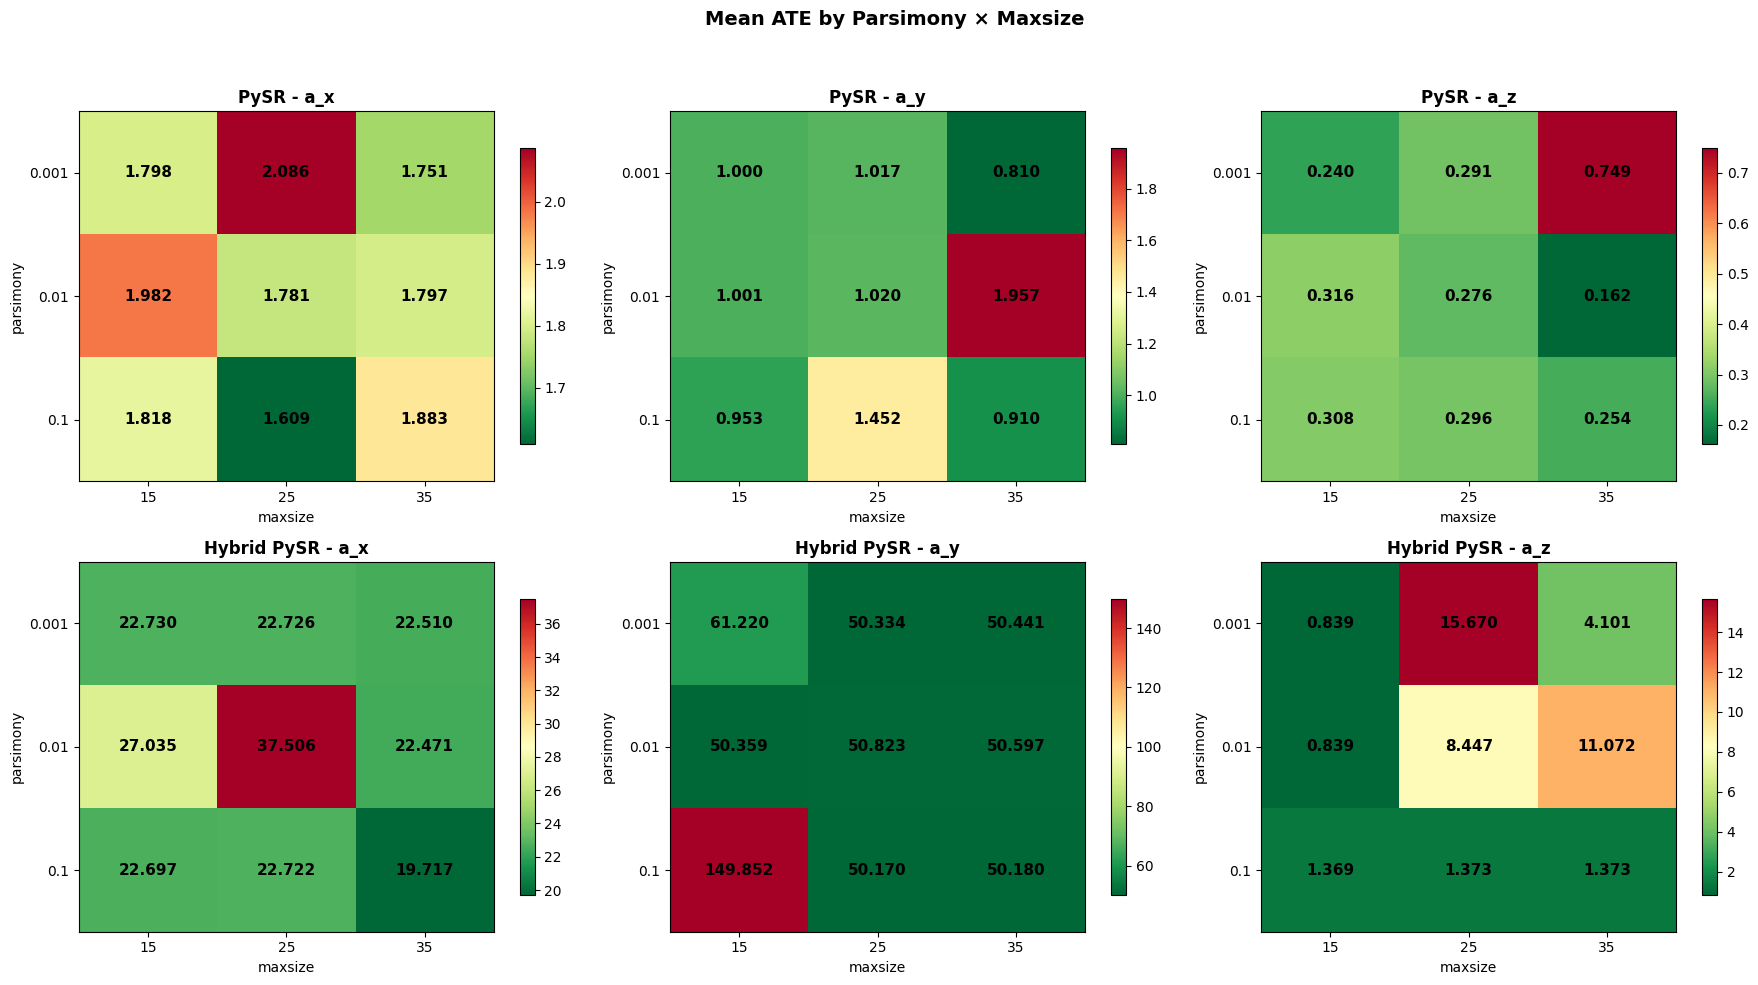

Hyperparameter heatmap saved.


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Mean ATE by Parsimony × Maxsize', fontsize=14, fontweight='bold')

for col, dof in enumerate(DOF_LABELS):
    for row, algo in enumerate(['PySR', 'Hybrid PySR']):
        ax = axes[row, col]
        sub = df_pysr[(df_pysr['algorithm'] == algo) & (df_pysr['dof'] == dof)]
        piv = sub.pivot_table(index='parsimony', columns='maxsize',
                              values='ATE', aggfunc='mean')
        if piv.empty:
            ax.set_title(f'{algo} - {dof} (no data)'); continue
        im = ax.imshow(piv.values, cmap='RdYlGn_r', aspect='auto')
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f'{v}' for v in piv.index])
        ax.set_xlabel('maxsize')
        ax.set_ylabel('parsimony')
        ax.set_title(f'{algo} - {dof}', fontweight='bold')
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                            fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(str(DATA_DIR), 'hoop_pysr_hyperparam_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Hyperparameter heatmap saved.')

## S6 — Internal Comparison: PySR vs Hybrid PySR

Best config per (algorithm × library × DOF), compared on MSE / R² / ATE.

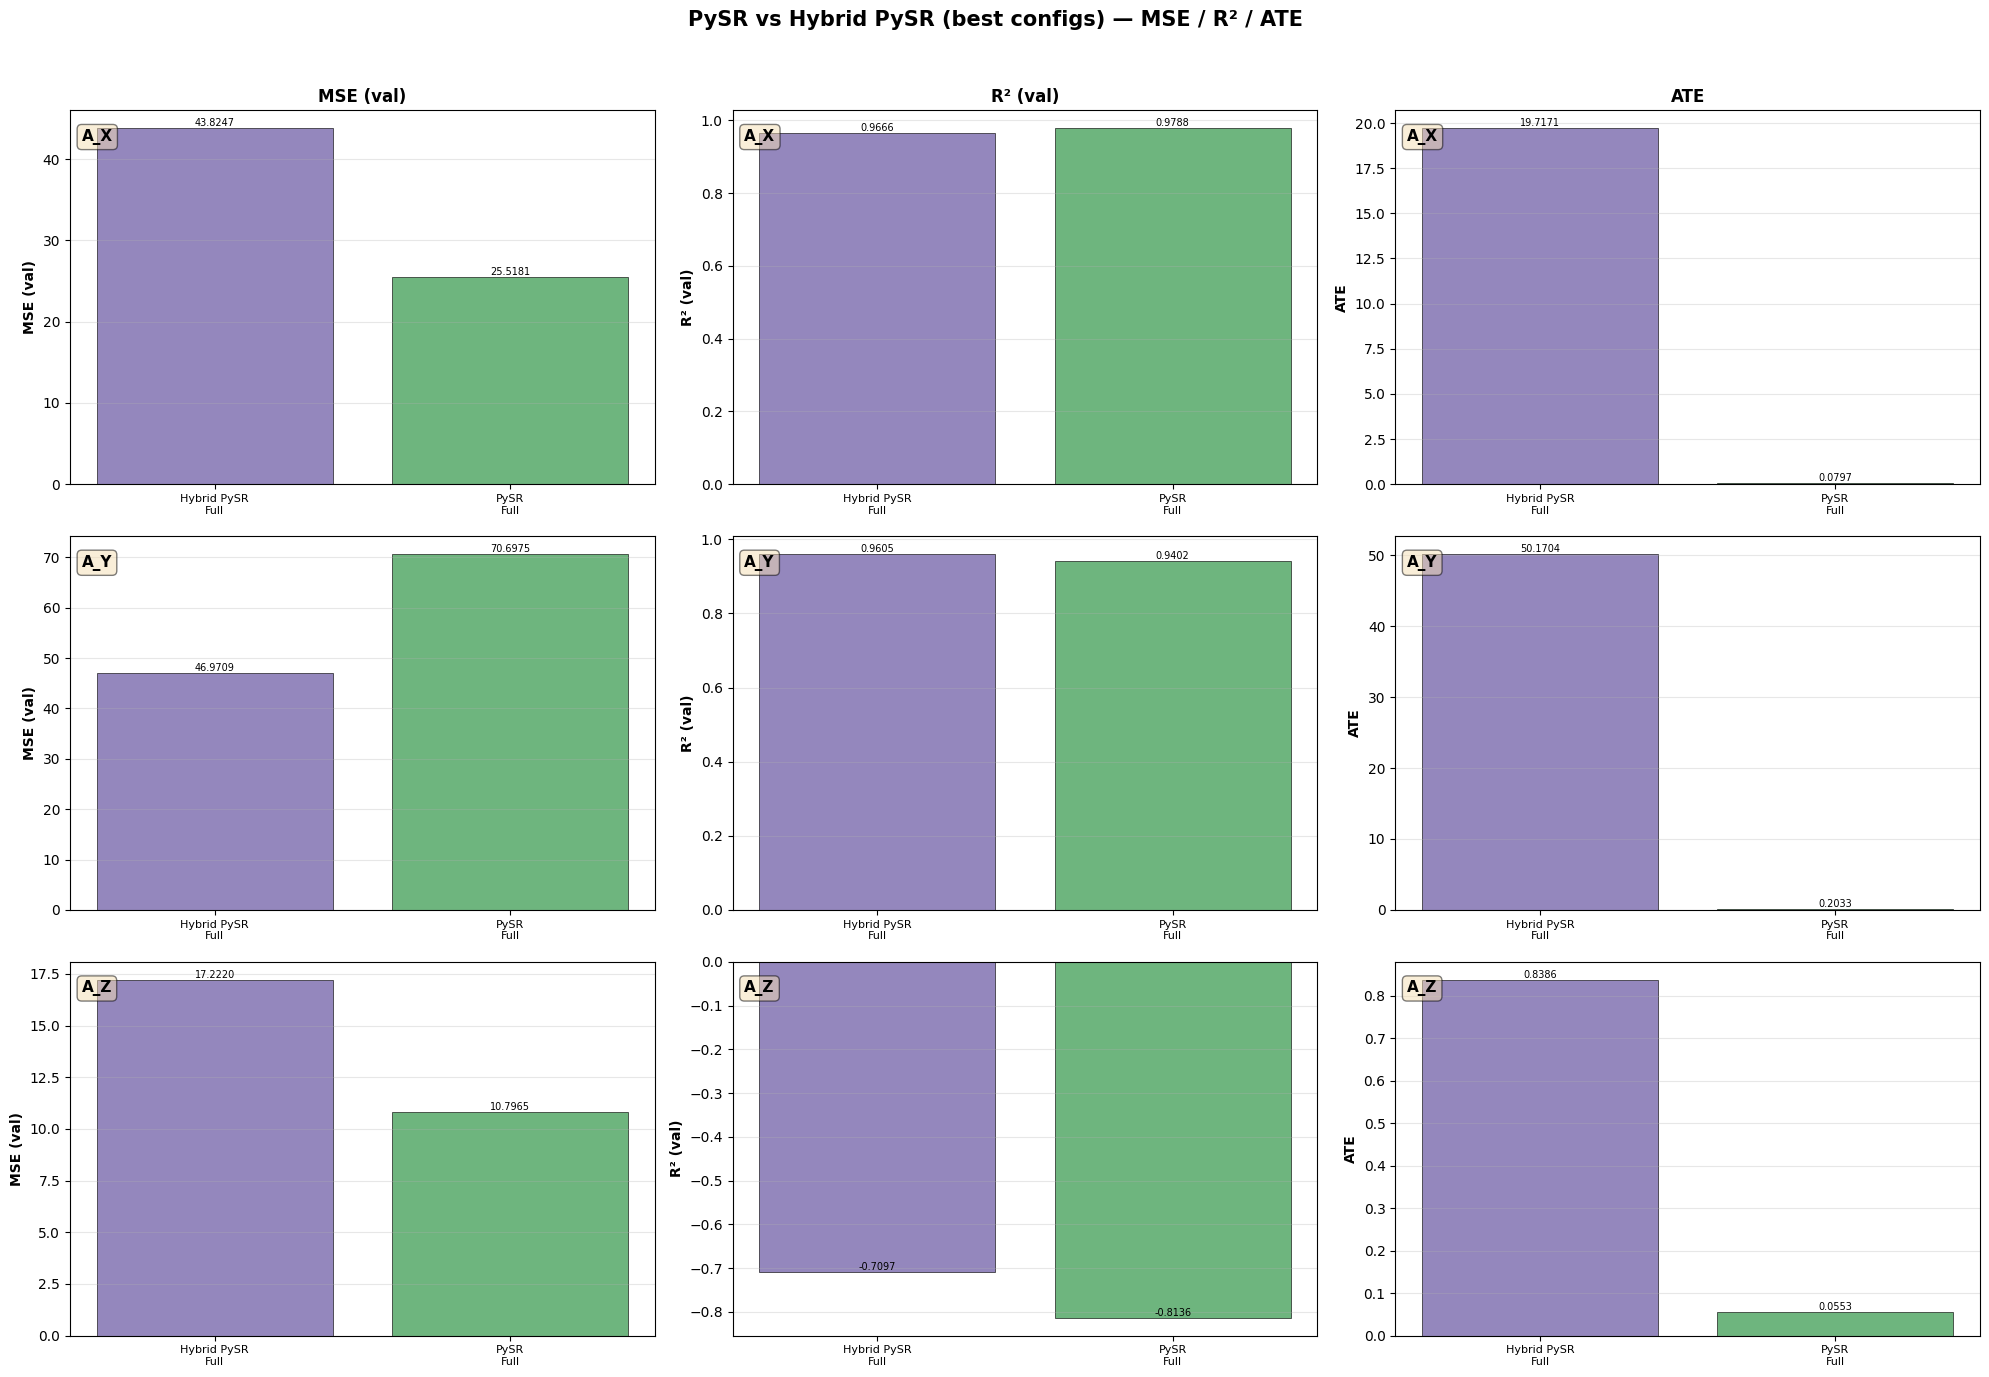

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle('PySR vs Hybrid PySR (best configs) — MSE / R² / ATE', fontsize=15, fontweight='bold')

# best config per (algo, lib, dof) by ATE
idx_best = df_pysr.groupby(['algorithm','library','dof'])['ATE'].idxmin()
df_best = df_pysr.loc[idx_best].copy()

metrics = [('MSE_val', 'MSE (val)'), ('R2_val', 'R² (val)'), ('ATE', 'ATE')]
for col, (metric, ylabel) in enumerate(metrics):
    for row, dof in enumerate(DOF_LABELS):
        ax = axes[row, col]
        sub = df_best[df_best['dof'] == dof]
        groups = sub.groupby(['algorithm','library'])[metric].mean().reset_index()
        labels = [f'{a}\n{l}' for a, l in zip(groups['algorithm'], groups['library'])]
        cmap_bars = {'PySR/Base':'#4C72B0', 'PySR/Full':'#55A868',
                     'Hybrid PySR/Base':'#C44E52', 'Hybrid PySR/Full':'#8172B2'}
        colors = [cmap_bars.get(f'{a}/{l}', 'grey') for a, l in zip(groups['algorithm'], groups['library'])]
        bars = ax.bar(range(len(groups)), groups[metric], color=colors,
                      alpha=0.85, edgecolor='black', linewidth=0.5)
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel(ylabel, fontweight='bold')
        if row == 0: ax.set_title(ylabel, fontsize=12, fontweight='bold')
        ax.text(0.02, 0.95, dof.upper(), transform=ax.transAxes, fontsize=11,
                fontweight='bold', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, groups[metric]):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                    f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(str(DATA_DIR), 'hoop_pysr_internal_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## S7 — Best Equations

In [24]:
print('=' * 90)
print('BEST EQUATIONS (by ATE per algorithm × run/pooled × DOF)')
print('=' * 90)

for algo in ['PySR', 'Hybrid PySR']:
    print(f'\n--- {algo} ---')
    sub = df_pysr[df_pysr['algorithm'] == algo]
    runs_list = RUNS if algo == 'PySR' else ['pooled']
    for rn in runs_list:
        print(f'\n  {rn.upper()}:')
        for dof in DOF_LABELS:
            rows = sub[(sub['run'] == rn) & (sub['dof'] == dof)]
            if len(rows) == 0: continue
            best = rows.loc[rows['ATE'].idxmin()]
            eq = best['equation']
            if len(eq) > 95: eq = eq[:92] + '...'
            print(f'    {dof} [{best["library"]} p={best["parsimony"]} ms={best["maxsize"]}]'
                  f' ATE={best["ATE"]:.4f}({best["ate_grade"]}) R2={best["R2_val"]:.3f}')
            print(f'      {eq}')

BEST EQUATIONS (by ATE per algorithm × run/pooled × DOF)

--- PySR ---

  RUN_1:
    a_x [Full p=0.01 ms=35] ATE=3.1323(F) R2=0.984
      (sin_ez + vy*0.10647753 + vy)/0.09264876
    a_y [Full p=0.1 ms=15] ATE=0.9492(F) R2=0.976
      (-(-1.185085)*cos_ez + vx)*(-13.313842)
    a_z [Full p=0.001 ms=15] ATE=0.0562(C) R2=0.694
      px - vx

  RUN_2:
    a_x [Full p=0.1 ms=25] ATE=1.0335(F) R2=0.972
      (px*3.9437196 + vy)/0.056522425 - 0.6715556
    a_y [Full p=0.01 ms=25] ATE=0.2033(D) R2=0.940
      vx*(-10.822877)
    a_z [Full p=0.001 ms=35] ATE=0.0731(C) R2=0.371
      (-alphax + ay)*0.08116606

  RUN_3:
    a_x [Full p=0.1 ms=35] ATE=1.3126(F) R2=0.966
      py + (sin_ez + vy)/0.07668739 - 1*(-0.23544516)
    a_y [Full p=0.1 ms=35] ATE=0.5840(F) R2=0.961
      -11.81122*(cos_ez + vx) - 0.05406851
    a_z [Full p=0.001 ms=25] ATE=0.0553(C) R2=-0.814
      ay*0.087150045

  RUN_4:
    a_x [Full p=0.001 ms=35] ATE=0.0797(C) R2=0.979
      (sin_ez*(-1.2492924) - vy)*(-13.048119)
   

## S8 — Cross-Method Comparison: PySR vs SINDy Pipeline

Load SINDy sweep results and compare best configs head-to-head.

In [25]:
sindy_csv = os.path.join(str(DATA_DIR), 'hoop_full_sweep_results.csv')
df_sindy = pd.read_csv(sindy_csv)
print(f'SINDy results: {len(df_sindy)} rows, algorithms: {list(df_sindy["algorithm"].unique())}')

# best SINDy config per (algo, run, dof) — averaged across runs
sindy_best = []
for algo in df_sindy['algorithm'].unique():
    sub = df_sindy[df_sindy['algorithm'] == algo]
    for dof in DOF_LABELS:
        rows = sub[sub['dof'] == dof].dropna(subset=['ATE'])
        if len(rows) == 0: continue
        b = rows.loc[rows['ATE'].idxmin()]
        sindy_best.append({
            'algorithm': b['algorithm'], 'dof': dof,
            'library': b['library'],
            'MSE_val': b['MSE_val'], 'MSE_test': b['MSE_test'],
            'R2_val': b.get('R2_val', np.nan), 'R2_test': b['R2_test'],
            'ATE': b['ATE'], 'ate_grade': b['ate_grade'],
        })

# best PySR config per (algo, dof)
pysr_best = []
for algo in ['PySR', 'Hybrid PySR']:
    sub = df_pysr[df_pysr['algorithm'] == algo]
    for dof in DOF_LABELS:
        rows = sub[sub['dof'] == dof].dropna(subset=['ATE'])
        if len(rows) == 0: continue
        b = rows.loc[rows['ATE'].idxmin()]
        pysr_best.append({
            'algorithm': b['algorithm'], 'dof': dof,
            'library': b['library'],
            'MSE_val': b['MSE_val'], 'MSE_test': b['MSE_test'],
            'R2_val': b['R2_val'], 'R2_test': b['R2_test'],
            'ATE': b['ATE'], 'ate_grade': b['ate_grade'],
        })

df_cross = pd.concat([pd.DataFrame(sindy_best), pd.DataFrame(pysr_best)], ignore_index=True)
print(f'\nCross-comparison: {len(df_cross)} best configs')
print(df_cross.groupby('algorithm')[['MSE_val','R2_val','ATE']].mean().to_string())

SINDy results: 3240 rows, algorithms: ['SINDy', 'Lagrange', 'Hybrid']

Cross-comparison: 15 best configs
               MSE_val    R2_val        ATE
algorithm                                  
Hybrid       26.608848  0.861061   0.162887
Hybrid PySR  36.005859  0.405813  23.575361
Lagrange     29.738925  0.714114   0.081678
PySR         35.670731  0.368459   0.112793
SINDy        23.324488  0.899911   0.044703


## S8b — Cross-Method Plots

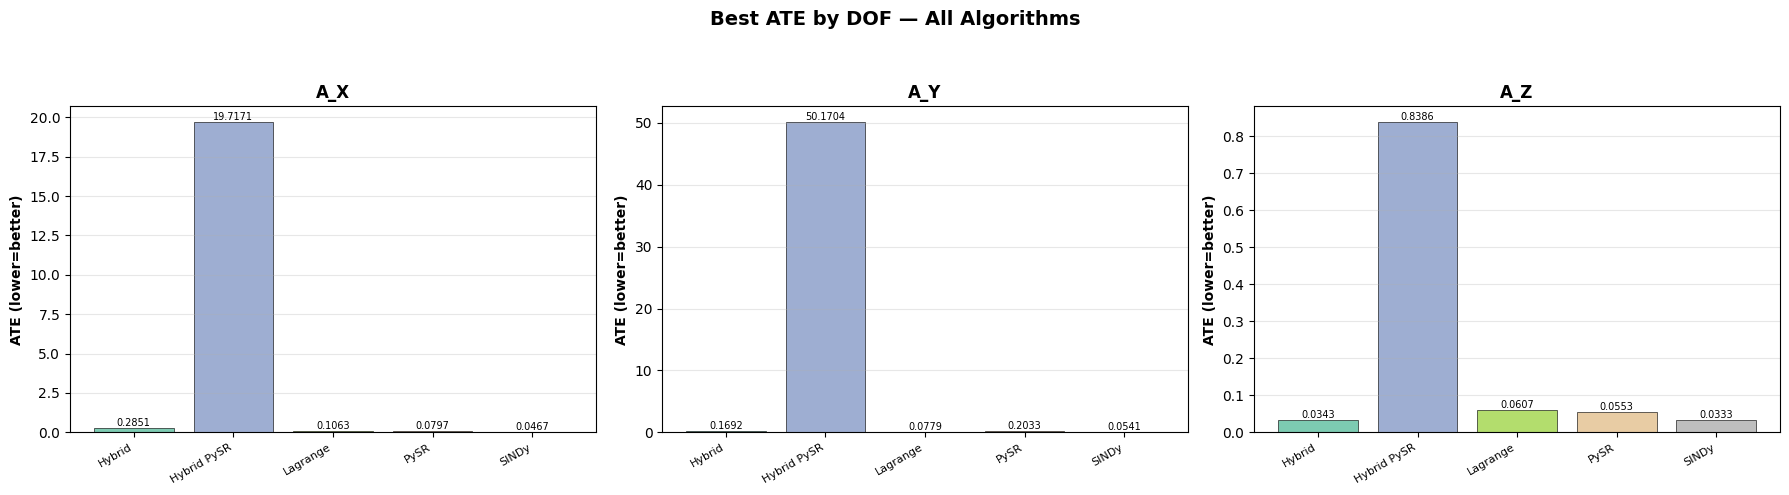

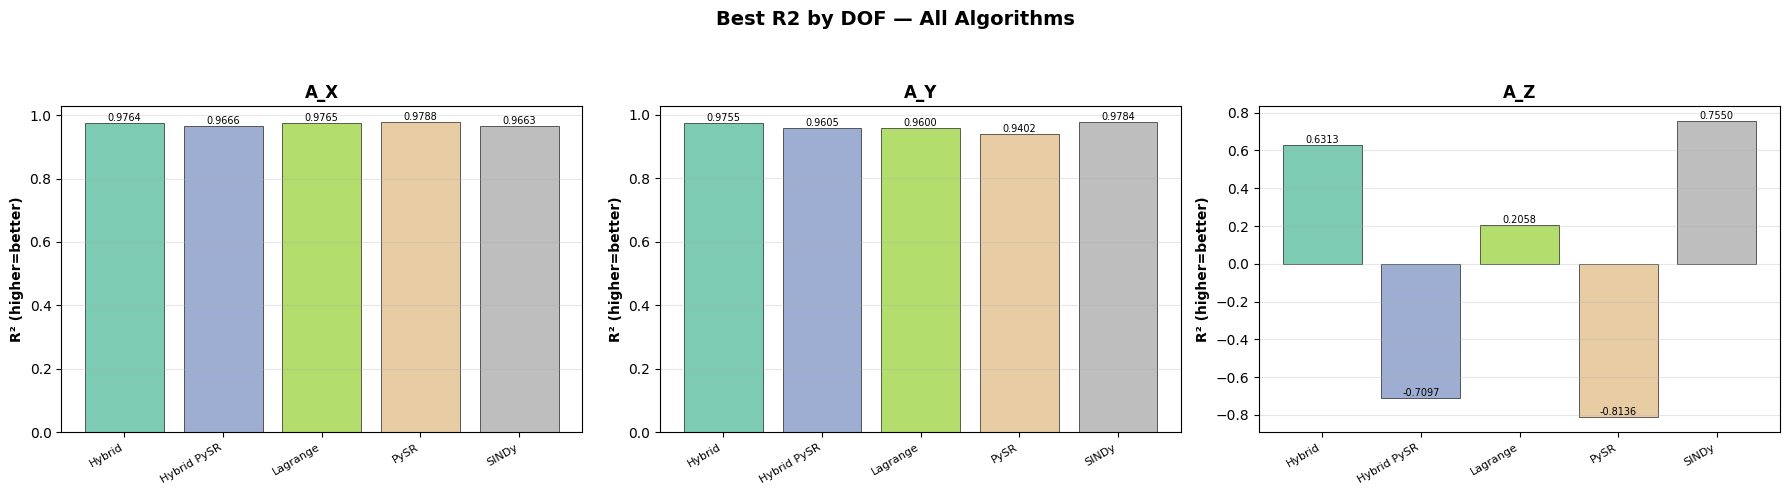

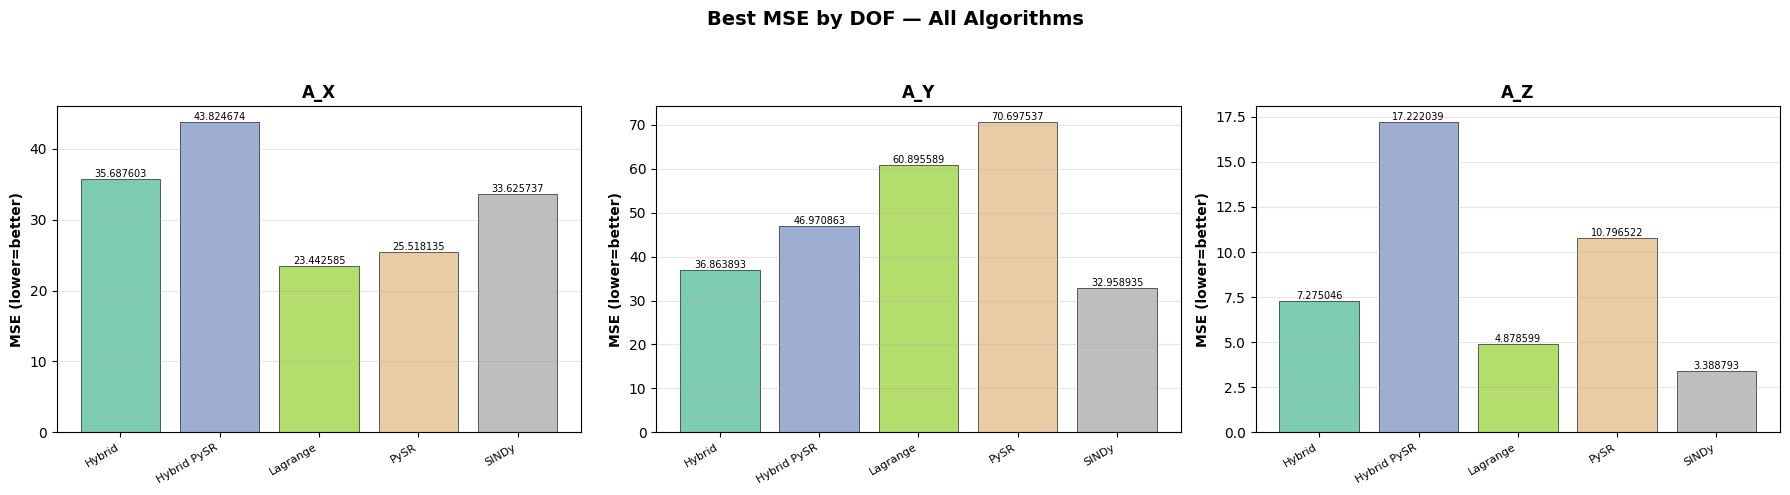

Cross-method plots saved.


In [26]:
all_algos = sorted(df_cross['algorithm'].unique())
cmap_cross = plt.cm.Set2
acolors = {a: cmap_cross(i / max(len(all_algos)-1, 1)) for i, a in enumerate(all_algos)}

for metric, ylabel, title_word in [
    ('ATE', 'ATE (lower=better)', 'ATE'),
    ('R2_val', 'R² (higher=better)', 'R2'),
    ('MSE_val', 'MSE (lower=better)', 'MSE'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Best {title_word} by DOF — All Algorithms', fontsize=14, fontweight='bold')
    for i, dof in enumerate(DOF_LABELS):
        ax = axes[i]
        sub = df_cross[df_cross['dof'] == dof]
        vals = sub.groupby('algorithm')[metric].mean().reindex(all_algos)
        bars = ax.bar(range(len(all_algos)), vals.values,
                      color=[acolors[a] for a in all_algos],
                      edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.set_xticks(range(len(all_algos)))
        ax.set_xticklabels(all_algos, fontsize=8, rotation=30, ha='right')
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_title(dof.upper(), fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        fmt = '.6f' if 'MSE' in metric else '.4f'
        for bar, val in zip(bars, vals.values):
            if np.isfinite(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                        f'{val:{fmt}}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(os.path.join(str(DATA_DIR), f'hoop_cross_method_{title_word.lower()}.png'),
               dpi=150, bbox_inches='tight')
    plt.show()
print('Cross-method plots saved.')

## S9 — ATE Grade Heatmap: All Methods

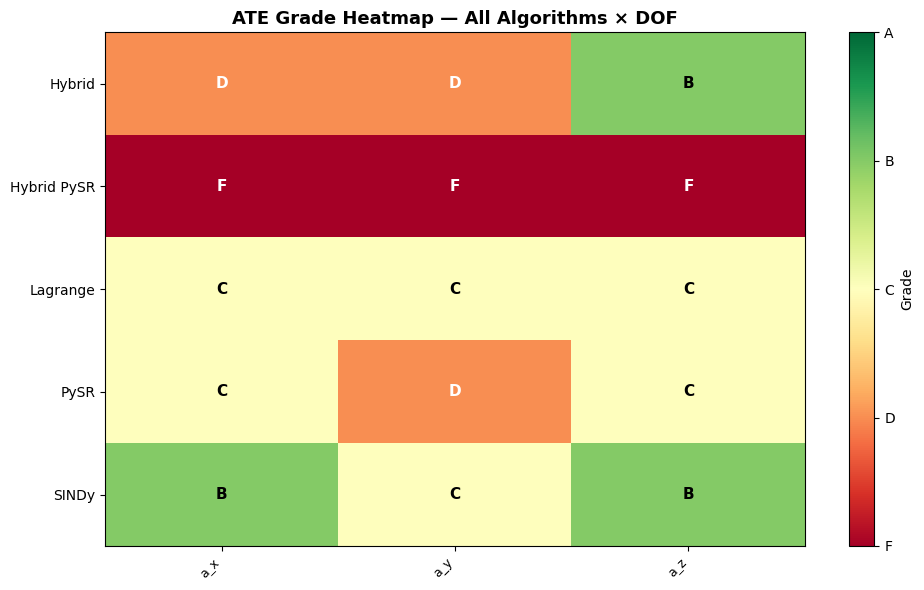

In [27]:
grade_map = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'F': 0}
grade_labels = {4: 'A', 3: 'B', 2: 'C', 1: 'D', 0: 'F'}

df_cross['grade_num'] = df_cross['ate_grade'].map(grade_map)
pivot = df_cross.pivot_table(index='algorithm', columns='dof',
                             values='grade_num', aggfunc='max')

fig, ax = plt.subplots(figsize=(10, 4 + 0.4 * len(all_algos)))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=4, aspect='auto')
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(pivot.index, fontsize=10)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if np.isfinite(val):
            lbl = grade_labels.get(int(val), '?')
            ax.text(j, i, lbl, ha='center', va='center', fontsize=11,
                    fontweight='bold', color='white' if val <= 1 else 'black')
ax.set_title('ATE Grade Heatmap — All Algorithms × DOF',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, ticks=[0,1,2,3,4], label='Grade',
             format=plt.FuncFormatter(lambda x, _: grade_labels.get(int(x), '')))
plt.tight_layout()
plt.savefig(os.path.join(str(DATA_DIR), 'hoop_cross_method_grade_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## S10 — Final Summary

In [28]:
print('=' * 80)
print('  FINAL SUMMARY — ALL ALGORITHMS')
print('=' * 80)

algo_summary = df_cross.groupby('algorithm').agg(
    ATE_mean=('ATE', 'mean'), ATE_min=('ATE', 'min'),
    R2_mean=('R2_val', 'mean'), R2_max=('R2_val', 'max'),
    MSE_mean=('MSE_val', 'mean'), MSE_min=('MSE_val', 'min'),
).sort_values('ATE_mean')

print('\n  Ranked by mean ATE (lower is better):')
print(algo_summary.to_string())

best_ate = algo_summary.index[0]
best_r2  = algo_summary['R2_mean'].idxmax()
best_mse = algo_summary['MSE_mean'].idxmin()
print(f'\n  Best by ATE:  {best_ate} ({algo_summary.loc[best_ate, "ATE_mean"]:.4f})')
print(f'  Best by R²:   {best_r2} ({algo_summary.loc[best_r2, "R2_mean"]:.4f})')
print(f'  Best by MSE:  {best_mse} ({algo_summary.loc[best_mse, "MSE_mean"]:.6f})')

print(f'\n--- Per-DOF winners (best ATE) ---')
for dof in DOF_LABELS:
    sub = df_cross[df_cross['dof'] == dof]
    w = sub.loc[sub['ATE'].idxmin()]
    print(f'  {dof.upper():6s} -> {w["algorithm"]:14s} ATE={w["ATE"]:.4f}({w["ate_grade"]})')

print(f'\n--- Library effect (PySR algorithms) ---')
for algo in ['PySR', 'Hybrid PySR']:
    sub = df_pysr[df_pysr['algorithm'] == algo]
    base_ate = sub[sub['library'] == 'Base']['ATE'].mean()
    full_ate = sub[sub['library'] == 'Full']['ATE'].mean()
    delta = ((base_ate - full_ate) / base_ate * 100) if base_ate > 0 else 0
    better = 'Full' if full_ate < base_ate else 'Base'
    print(f'  {algo:14s}: Base={base_ate:.4f} Full={full_ate:.4f} -> {better} ({abs(delta):.1f}%)')

print(f'\n--- Hyperparameter effect ---')
for param in ['parsimony', 'maxsize']:
    print(f'\n  {param}:')
    grp = df_pysr.groupby(param)['ATE'].agg(['mean', 'min'])
    for val, row in grp.iterrows():
        print(f'    {val}: mean_ATE={row["mean"]:.4f} min_ATE={row["min"]:.4f}')

print(f'\n--- ATE Grade Distribution ---')
gct = pd.crosstab(df_cross['algorithm'], df_cross['ate_grade'])
for g in ['A','B','C','D','F']:
    if g not in gct.columns: gct[g] = 0
print(gct[['A','B','C','D','F']].to_string())

print(f'\n{"="*80}')
print(f'  PySR configs:     {len(df_pysr)}')
print(f'  Cross-comparison: {len(df_cross)}')
print(f'  Results:          hoop_pysr_sweep_results.csv')
print(f'{"="*80}')

  FINAL SUMMARY — ALL ALGORITHMS

  Ranked by mean ATE (lower is better):
              ATE_mean   ATE_min   R2_mean    R2_max   MSE_mean    MSE_min
algorithm                                                                 
SINDy         0.044703  0.033301  0.899911  0.978376  23.324488   3.388793
Lagrange      0.081678  0.060744  0.714114  0.976516  29.738925   4.878599
PySR          0.112793  0.055345  0.368459  0.978757  35.670731  10.796522
Hybrid        0.162887  0.034343  0.861061  0.976404  26.608848   7.275046
Hybrid PySR  23.575361  0.838621  0.405813  0.966630  36.005859  17.222039

  Best by ATE:  SINDy (0.0447)
  Best by R²:   SINDy (0.8999)
  Best by MSE:  SINDy (23.324488)

--- Per-DOF winners (best ATE) ---
  A_X    -> SINDy          ATE=0.0467(B)
  A_Y    -> SINDy          ATE=0.0541(C)
  A_Z    -> SINDy          ATE=0.0333(B)

--- Library effect (PySR algorithms) ---
  PySR          : Base=nan Full=1.0931 -> Base (0.0%)
  Hybrid PySR   : Base=nan Full=30.7101 -> Base (

## S11 — Grade Distribution per Algorithm × Library (Table 3)

  TABLE 3: Grade Distribution per Algorithm × Library


,ate_grade,A,B,C,D,F,Total,%A,%A+B
algorithm,library,,,,,,,,
Hybrid PySR,Full,0,0,0,0,27,27,0.000000,0.000000
PySR,Full,0,0,19,34,82,135,0.000000,0.000000


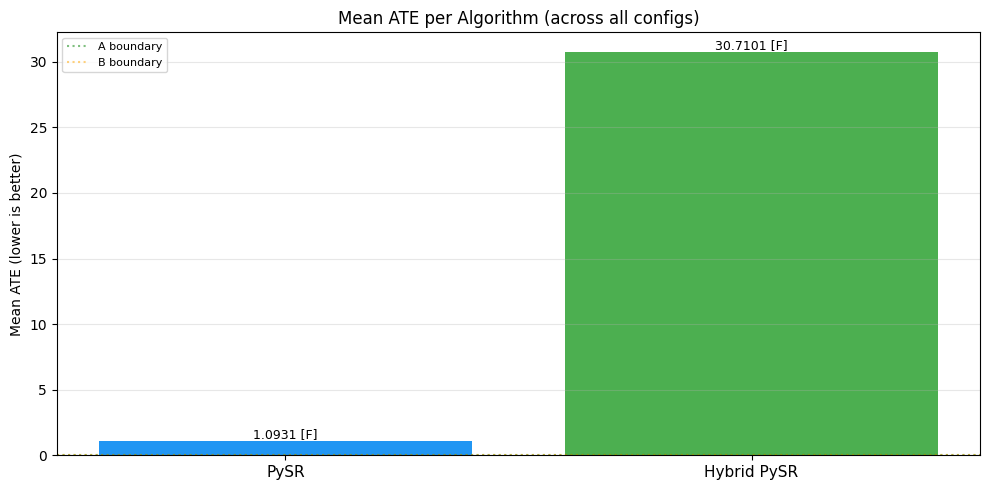

In [29]:
# ── Table 3: Grade Distribution per Algorithm × Library ──
print('='*70)
print('  TABLE 3: Grade Distribution per Algorithm × Library')
print('='*70)

gd2 = df_pysr.groupby(['algorithm','library'])['ate_grade'].value_counts().unstack(fill_value=0)
for g in ['A','B','C','D','F']:
    if g not in gd2.columns:
        gd2[g] = 0
gd2 = gd2[['A','B','C','D','F']]
gd2['Total'] = gd2.sum(axis=1)
gd2['%A'] = (gd2['A'] / gd2['Total'] * 100).round(1)
gd2['%A+B'] = ((gd2['A'] + gd2['B']) / gd2['Total'] * 100).round(1)

def _col_grade_bg(col):
    cmap_g = {'A':'#c6efce','B':'#dff0d8','C':'#fcf8e3','D':'#f2dede','F':'#d9534f'}
    bg = cmap_g.get(col.name, 'white')
    return [f'background-color:{bg}' if v > 0 else '' for v in col]

styled_gd2 = (gd2.style
              .apply(_col_grade_bg, axis=0, subset=['A','B','C','D','F'])
              .set_caption('Grade Distribution: Algorithm × Library')
              .set_table_styles([
                  {'selector':'caption','props':'font-size:13px;font-weight:bold;margin-bottom:6px'},
                  {'selector':'th','props':'background-color:#34495e;color:white;padding:5px 12px;text-align:center'},
                  {'selector':'td','props':'text-align:center;padding:4px 12px'},
              ]))
display(styled_gd2)

# ── Bar chart: mean ATE per algorithm ──
fig, ax = plt.subplots(figsize=(10, 5))
algo_ate = df_pysr.groupby('algorithm')['ATE'].mean().sort_values()
colors = ['#2196F3', '#4CAF50']
bars = ax.bar(range(len(algo_ate)), algo_ate.values, color=colors[:len(algo_ate)])
ax.set_xticks(range(len(algo_ate)))
ax.set_xticklabels(algo_ate.index, fontsize=11)
ax.set_ylabel('Mean ATE (lower is better)')
ax.set_title('Mean ATE per Algorithm (across all configs)')
for bar, v in zip(bars, algo_ate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
            f'{v:.4f} [{ate_grade(v)}]', ha='center', va='bottom', fontsize=9)
ax.axhline(0.01, color='green', ls=':', alpha=0.5, label='A boundary')
ax.axhline(0.05, color='orange', ls=':', alpha=0.5, label='B boundary')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## S12 — Sparsity Check & Train/Val/Test Comparison

PySR uses evolutionary search — equations can grow up to `maxsize` complexity.
Check whether expressions are sparse enough, and compare MSE / R² across splits.

  SPARSITY CHECK: Equation Complexity (n_terms)

  Overall: mean=6.7, median=5, max=30, min=3
  Equations with >=12 terms: 11 / 162 (7%)
  Equations with >=15 terms: 9 / 162 (6%)


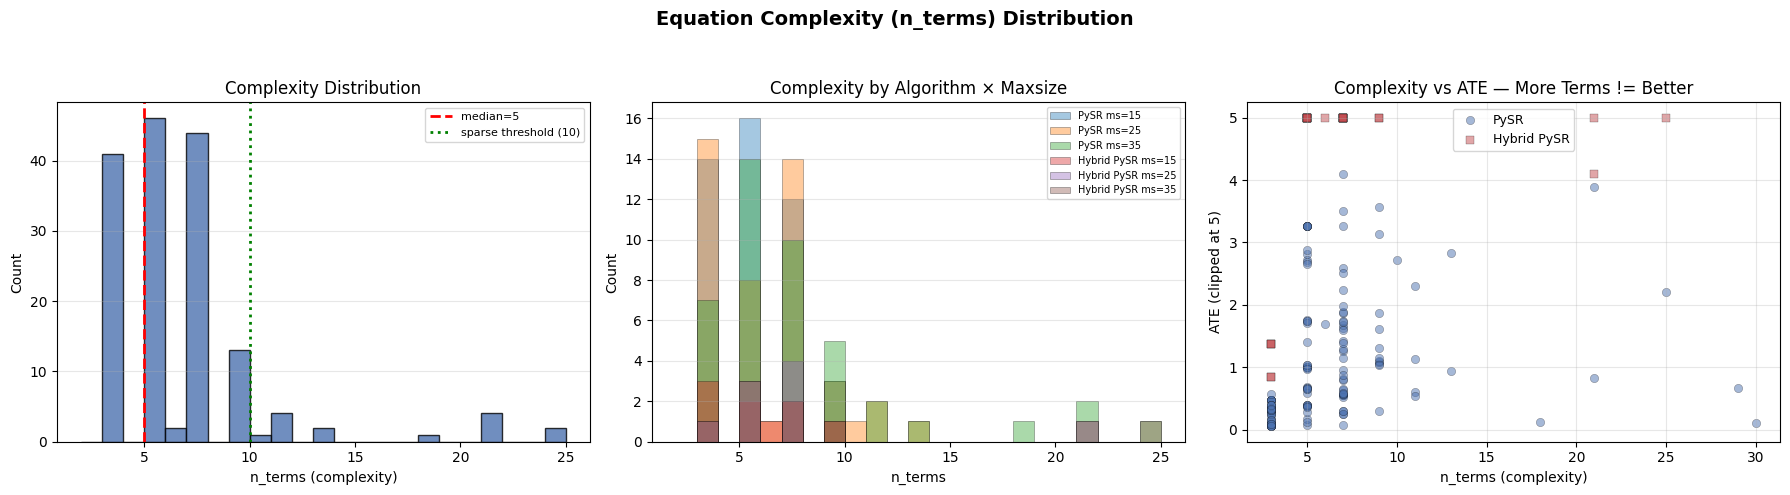


  Complexity by (algorithm, maxsize):
                     mean  median  max
algorithm   maxsize                   
Hybrid PySR 15        5.3     5.0    9
            25        7.4     7.0   21
            35        9.7     7.0   25
PySR        15        5.2     5.0    9
            25        5.8     5.0   13
            35        8.6     7.0   30


In [30]:
# ── Sparsity / Complexity Analysis ──
print('='*70)
print('  SPARSITY CHECK: Equation Complexity (n_terms)')
print('='*70)

print(f'\n  Overall: mean={df_pysr["n_terms"].mean():.1f}, '
      f'median={df_pysr["n_terms"].median():.0f}, '
      f'max={df_pysr["n_terms"].max()}, min={df_pysr["n_terms"].min()}')
print(f'  Equations with >=12 terms: {(df_pysr["n_terms"]>=12).sum()} / {len(df_pysr)} '
      f'({(df_pysr["n_terms"]>=12).mean()*100:.0f}%)')
print(f'  Equations with >=15 terms: {(df_pysr["n_terms"]>=15).sum()} / {len(df_pysr)} '
      f'({(df_pysr["n_terms"]>=15).mean()*100:.0f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Equation Complexity (n_terms) Distribution', fontsize=14, fontweight='bold')

# 1) Histogram of n_terms
ax = axes[0]
ax.hist(df_pysr['n_terms'], bins=range(2, 26), color='#4C72B0', edgecolor='black', alpha=0.8)
ax.axvline(df_pysr['n_terms'].median(), color='red', ls='--', lw=2,
           label=f'median={df_pysr["n_terms"].median():.0f}')
ax.axvline(10, color='green', ls=':', lw=2, label='sparse threshold (10)')
ax.set_xlabel('n_terms (complexity)')
ax.set_ylabel('Count')
ax.set_title('Complexity Distribution')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# 2) n_terms by algorithm x maxsize
ax = axes[1]
for algo in ['PySR', 'Hybrid PySR']:
    for ms in MAXSIZE_VALUES:
        sub = df_pysr[(df_pysr['algorithm']==algo) & (df_pysr['maxsize']==ms)]
        label = f'{algo} ms={ms}'
        ax.hist(sub['n_terms'], bins=range(2, 26), alpha=0.4, label=label,
                edgecolor='black', linewidth=0.5)
ax.set_xlabel('n_terms')
ax.set_ylabel('Count')
ax.set_title('Complexity by Algorithm × Maxsize')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

# 3) n_terms vs ATE scatter
ax = axes[2]
for algo, marker, color in [('PySR', 'o', '#4C72B0'), ('Hybrid PySR', 's', '#C44E52')]:
    sub = df_pysr[df_pysr['algorithm']==algo]
    ax.scatter(sub['n_terms'], sub['ATE'].clip(upper=5), alpha=0.5,
               marker=marker, color=color, label=algo, edgecolors='black', linewidth=0.3)
ax.set_xlabel('n_terms (complexity)')
ax.set_ylabel('ATE (clipped at 5)')
ax.set_title('Complexity vs ATE — More Terms != Better')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Summary table
print('\n  Complexity by (algorithm, maxsize):')
cplx = df_pysr.groupby(['algorithm','maxsize'])['n_terms'].agg(['mean','median','max']).round(1)
print(cplx.to_string())

  MSE COMPARISON: Train / Validation / Test


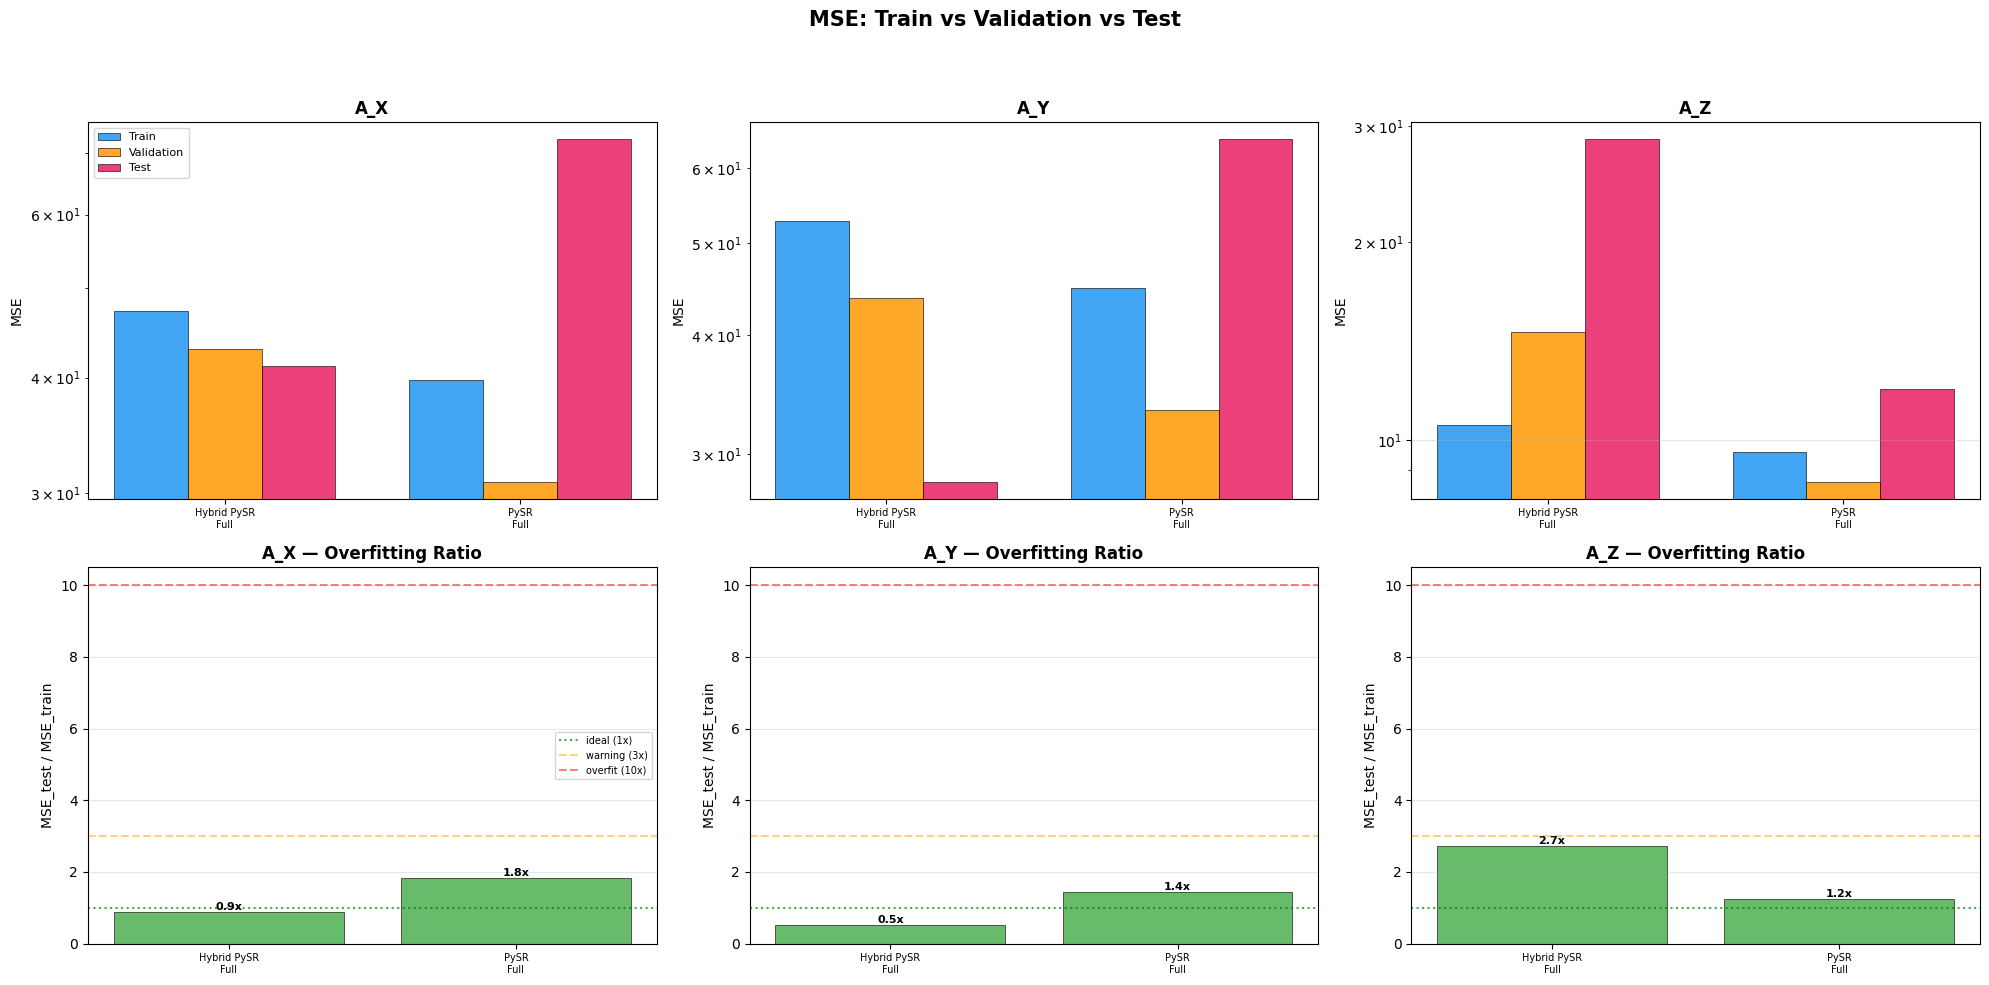


  MSE by algorithm (mean across all configs):
             MSE_train    MSE_val   MSE_test  test/train
algorithm                                               
Hybrid PySR  36.827698  33.774532  32.596054         0.9
PySR         31.390749  24.295316  49.522345         1.6


In [31]:
# ── MSE: Train vs Validation vs Test ──
print('='*70)
print('  MSE COMPARISON: Train / Validation / Test')
print('='*70)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('MSE: Train vs Validation vs Test', fontsize=15, fontweight='bold')

splits = ['MSE_train', 'MSE_val', 'MSE_test']
split_labels = ['Train', 'Validation', 'Test']
bar_colors = ['#2196F3', '#FF9800', '#E91E63']

# Row 0: grouped bars by algorithm x library
for col, dof in enumerate(DOF_LABELS):
    ax = axes[0, col]
    sub = df_pysr[df_pysr['dof'] == dof]
    groups = sub.groupby(['algorithm', 'library'])[splits].mean()
    x = np.arange(len(groups))
    w = 0.25
    for i, (sp, lbl, clr) in enumerate(zip(splits, split_labels, bar_colors)):
        bars = ax.bar(x + i*w, groups[sp].values, w, label=lbl, color=clr,
                      alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x + w)
    ax.set_xticklabels([f'{a}\n{l}' for a, l in groups.index], fontsize=7, rotation=0)
    ax.set_ylabel('MSE')
    ax.set_title(f'{dof.upper()}', fontweight='bold')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)
    if col == 0:
        ax.legend(fontsize=8)

# Row 1: overfitting ratio (test/train) by algorithm x library
for col, dof in enumerate(DOF_LABELS):
    ax = axes[1, col]
    sub = df_pysr[df_pysr['dof'] == dof]
    groups = sub.groupby(['algorithm', 'library'])[splits].mean()
    ratio = groups['MSE_test'] / groups['MSE_train'].clip(lower=1e-10)
    colors_ov = ['#4CAF50' if r < 3 else '#FF9800' if r < 10 else '#E91E63' for r in ratio]
    bars = ax.bar(range(len(ratio)), ratio.values, color=colors_ov,
                  edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.set_xticks(range(len(ratio)))
    ax.set_xticklabels([f'{a}\n{l}' for a, l in ratio.index], fontsize=7)
    ax.set_ylabel('MSE_test / MSE_train')
    ax.set_title(f'{dof.upper()} — Overfitting Ratio', fontweight='bold')
    ax.axhline(1, color='green', ls=':', alpha=0.7, label='ideal (1x)')
    ax.axhline(3, color='orange', ls='--', alpha=0.5, label='warning (3x)')
    ax.axhline(10, color='red', ls='--', alpha=0.5, label='overfit (10x)')
    for bar, v in zip(bars, ratio.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f'{v:.1f}x', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    if col == 0:
        ax.legend(fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Summary table
print('\n  MSE by algorithm (mean across all configs):')
mse_summary = df_pysr.groupby('algorithm')[splits].mean()
mse_summary['test/train'] = (mse_summary['MSE_test'] / mse_summary['MSE_train']).round(1)
print(mse_summary.to_string())

  R² ANALYSIS (corrected for divergent equations)
  Divergent models (R² < -1): val=6/162, test=2/162
  Negative R² (any):          val=18, test=23


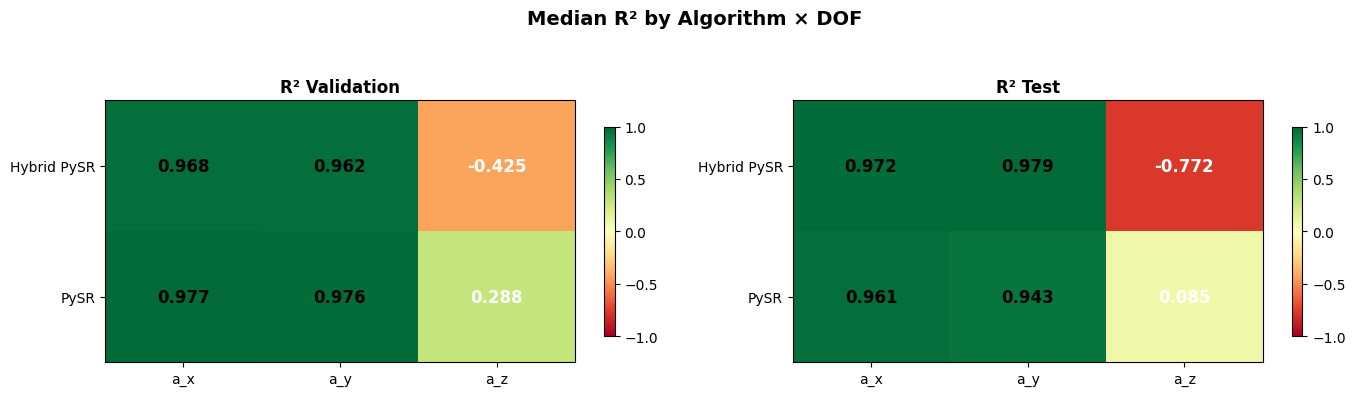

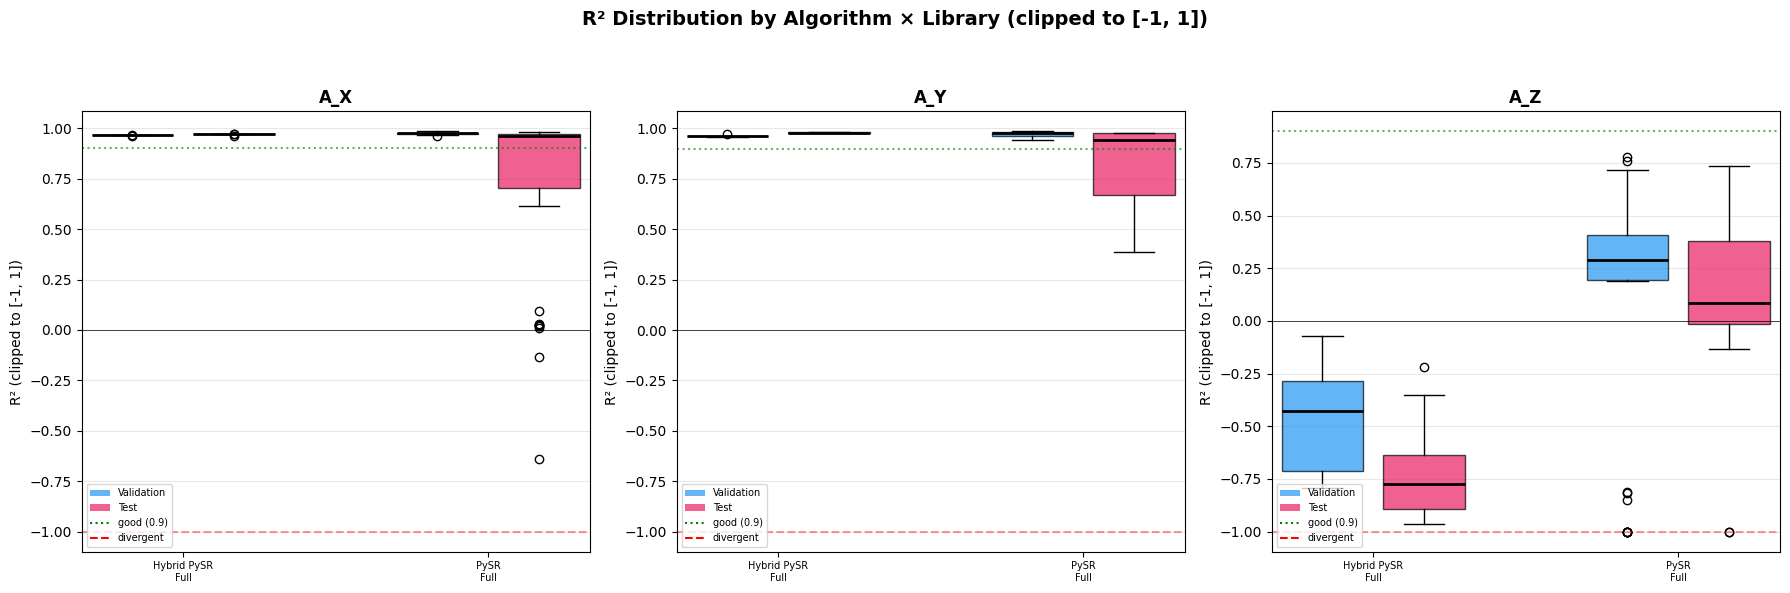

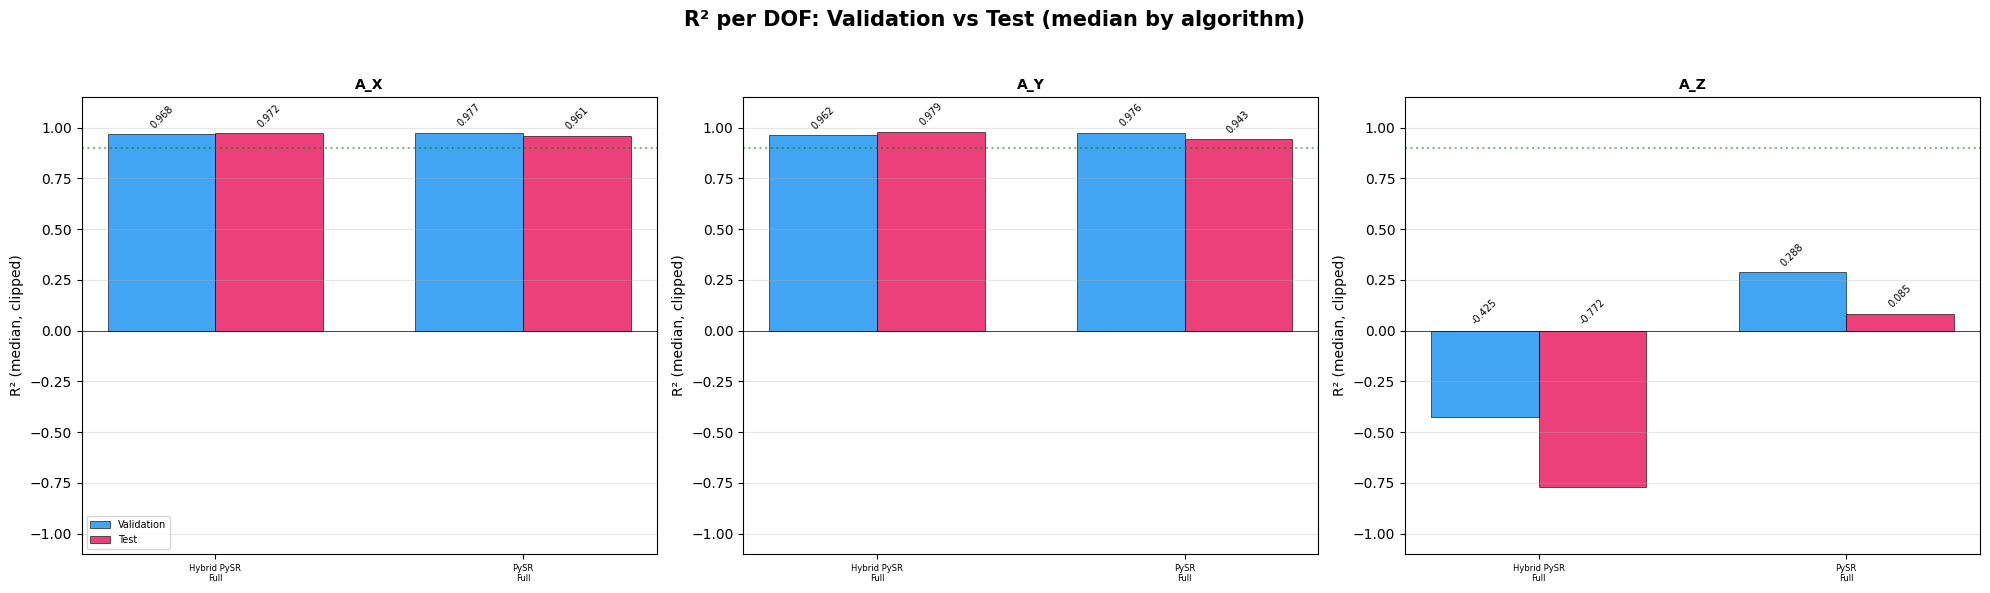


  Median R² by algorithm (clipped):
             R2_val_clip  R2_test_clip
algorithm                             
Hybrid PySR     0.962236      0.972229
PySR            0.969406      0.673892

  Median R² by algorithm × DOF (validation):
dof               a_x       a_y       a_z
algorithm                                
Hybrid PySR  0.967817  0.962236 -0.425407
PySR         0.976615  0.976351  0.287835

  Median R² by algorithm × DOF (test):
dof               a_x       a_y       a_z
algorithm                                
Hybrid PySR  0.972229  0.979390 -0.772487
PySR         0.961052  0.942718  0.084631

  DIAGNOSIS
  [POOR     ] Hybrid PySR/a_z: median R²_test = -0.772
  [WEAK     ] PySR/a_z: median R²_test = 0.085

  Strong fits (R²_test >= 0.9):
    Hybrid PySR/a_x: 0.972
    Hybrid PySR/a_y: 0.979
    PySR/a_x: 0.961
    PySR/a_y: 0.943


In [32]:
# ── R² Comparison: Validation vs Test (corrected for divergent equations) ──
print('='*70)
print('  R² ANALYSIS (corrected for divergent equations)')
print('='*70)

df_pysr['R2_val_clip']  = df_pysr['R2_val'].clip(lower=-1)
df_pysr['R2_test_clip'] = df_pysr['R2_test'].clip(lower=-1)
n_diverge_val  = (df_pysr['R2_val'] < -1).sum()
n_diverge_test = (df_pysr['R2_test'] < -1).sum()
print(f'  Divergent models (R² < -1): val={n_diverge_val}/{len(df_pysr)}, test={n_diverge_test}/{len(df_pysr)}')
print(f'  Negative R² (any):          val={(df_pysr["R2_val"]<0).sum()}, test={(df_pysr["R2_test"]<0).sum()}')

# ─── Plot 1: R² heatmap per DOF — median ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Median R² by Algorithm × DOF', fontsize=14, fontweight='bold')

for ax_i, (col_name, title) in enumerate([('R2_val_clip', 'R² Validation'), ('R2_test_clip', 'R² Test')]):
    ax = axes[ax_i]
    piv = df_pysr.pivot_table(index='algorithm', columns='dof', values=col_name, aggfunc='median')
    piv = piv.reindex(columns=DOF_LABELS)
    im = ax.imshow(piv.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(DOF_LABELS)))
    ax.set_xticklabels(DOF_LABELS, fontsize=10)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index, fontsize=10)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            color = 'white' if v < 0.3 else 'black'
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=12, fontweight='bold', color=color)
    ax.set_title(title, fontweight='bold', fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# ─── Plot 2: Box plots — R² distribution (clipped to [-1, 1]) ───
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('R² Distribution by Algorithm × Library (clipped to [-1, 1])', fontsize=14, fontweight='bold')

for col, dof in enumerate(DOF_LABELS):
    ax = axes[col]
    sub = df_pysr[df_pysr['dof'] == dof].copy()
    sub['group'] = sub['algorithm'] + '\n' + sub['library']
    groups = sorted(sub['group'].unique())

    for gi, grp in enumerate(groups):
        g = sub[sub['group'] == grp]
        ax.boxplot(g['R2_val_clip'].values, positions=[gi*3], widths=0.8,
                   patch_artist=True, boxprops=dict(facecolor='#2196F3', alpha=0.7),
                   medianprops=dict(color='black', linewidth=2))
        ax.boxplot(g['R2_test_clip'].values, positions=[gi*3+1], widths=0.8,
                   patch_artist=True, boxprops=dict(facecolor='#E91E63', alpha=0.7),
                   medianprops=dict(color='black', linewidth=2))

    ax.set_xticks([gi*3+0.5 for gi in range(len(groups))])
    ax.set_xticklabels(groups, fontsize=7)
    ax.set_ylabel('R² (clipped to [-1, 1])')
    ax.set_title(f'{dof.upper()}', fontweight='bold')
    ax.axhline(0.9, color='green', ls=':', alpha=0.6, label='good (0.9)')
    ax.axhline(0, color='black', ls='-', lw=0.5)
    ax.axhline(-1, color='red', ls='--', alpha=0.4, label='divergent floor')
    ax.grid(axis='y', alpha=0.3)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='#2196F3', alpha=0.7, label='Validation'),
                       Patch(facecolor='#E91E63', alpha=0.7, label='Test'),
                       plt.Line2D([],[],color='green',ls=':',label='good (0.9)'),
                       plt.Line2D([],[],color='red',ls='--',label='divergent')],
              fontsize=7, loc='lower left')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# ─── Plot 3: Per-DOF R² — validation vs test ───
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('R² per DOF: Validation vs Test (median by algorithm)', fontsize=15, fontweight='bold')

r2_clip_splits = ['R2_val_clip', 'R2_test_clip']
r2_labels = ['Validation', 'Test']
r2_colors = ['#2196F3', '#E91E63']

for col, dof in enumerate(DOF_LABELS):
    ax = axes[col]
    sub = df_pysr[df_pysr['dof'] == dof]
    groups = sub.groupby(['algorithm', 'library'])[r2_clip_splits].median()
    x = np.arange(len(groups))
    w = 0.35
    for i, (sp, lbl, clr) in enumerate(zip(r2_clip_splits, r2_labels, r2_colors)):
        bars = ax.bar(x + i*w, groups[sp].values, w, label=lbl, color=clr,
                      alpha=0.85, edgecolor='black', linewidth=0.5)
        for bar, v in zip(bars, groups[sp].values):
            ypos = max(bar.get_height(), 0) + 0.02
            ax.text(bar.get_x()+bar.get_width()/2, ypos,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)
    ax.set_xticks(x + w/2)
    ax.set_xticklabels([f'{a}\n{l}' for a, l in groups.index], fontsize=6)
    ax.set_ylabel('R² (median, clipped)')
    ax.axhline(0, color='black', ls='-', lw=0.5)
    ax.axhline(0.9, color='green', ls=':', alpha=0.5)
    ax.set_ylim(-1.1, 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{dof.upper()}', fontweight='bold', fontsize=10)
    if col == 0:
        ax.legend(fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ─── Summary tables ───
print('\n  Median R² by algorithm (clipped):')
r2_summary = df_pysr.groupby('algorithm')[r2_clip_splits].median()
print(r2_summary.to_string())

print('\n  Median R² by algorithm × DOF (validation):')
piv_val = df_pysr.pivot_table(index='algorithm', columns='dof', values='R2_val_clip', aggfunc='median')
print(piv_val.reindex(columns=DOF_LABELS).to_string())

print('\n  Median R² by algorithm × DOF (test):')
piv_test = df_pysr.pivot_table(index='algorithm', columns='dof', values='R2_test_clip', aggfunc='median')
print(piv_test.reindex(columns=DOF_LABELS).to_string())

# ─── Diagnosis ───
print('\n' + '='*70)
print('  DIAGNOSIS')
print('='*70)
problem_combos = df_pysr.groupby(['algorithm','dof'])['R2_test_clip'].median()
for (algo, dof), r2 in problem_combos.items():
    if r2 < 0.5:
        status = 'DIVERGENT' if r2 <= -1 else 'POOR' if r2 < 0 else 'WEAK'
        print(f'  [{status:9s}] {algo}/{dof}: median R²_test = {r2:.3f}')
good = problem_combos[problem_combos >= 0.9]
if len(good):
    print(f'\n  Strong fits (R²_test >= 0.9):')
    for (algo, dof), r2 in good.items():
        print(f'    {algo}/{dof}: {r2:.3f}')